# Progetto di Machine Learning: classificazione su un dataset di farmaci

**Gruppo:** _(Adabi_Farmaci_25/26)_  
**Dataset:** `real_drug_dataset.csv`  
**Ambiente utilizzato:** Google Colab

## Obiettivo principale

Costruire e confrontare modelli di classificazione multiclasse per prevedere `Drug_Name` a partire da:

- età;
- genere;
- condizione clinica.

Il notebook segue il workflow didattico completo illustrato a lezione:

1. controllo iniziale dei dati;
2. separazione tra training set e test set;
3. EDA sul training set;
4. preprocessing tramite `Pipeline`;
5. baseline;
6. cross-validation;
7. tuning degli iperparametri;
8. valutazione finale sul test set;
9. interpretazione dei risultati.


## 0. Prima di iniziare: qual è il problema?

Un progetto di Machine Learning deve partire da una domanda concreta.

### Task principale: classificazione multiclasse

Vogliamo prevedere la variabile `Drug_Name`, cioè il farmaco associato a un paziente, utilizzando alcune informazioni disponibili prima della scelta del trattamento:

- `Age`
- `Gender`
- `Condition`

Il target contiene più di due classi, quindi si tratta di un problema di **classificazione multiclasse**.

### Perché abbiamo scelto `Drug_Name` come target?

Nel primo tentativo il target era `Condition` e tra le feature era presente `Drug_Name`. Nel dataset, però, ogni farmaco è associato a una sola condizione clinica. Il modello poteva quindi ricostruire la condizione quasi direttamente dal nome del farmaco, ottenendo risultati perfetti ma poco informativi.

Invertendo il problema, il modello deve distinguere tra più farmaci possibili all'interno della stessa condizione. Il task diventa meno banale e permette di confrontare meglio i modelli.


In [ ]:
# Librerie principali
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    roc_auc_score
)

# Metodo del modulo random per generare numeri casuali in modo da poter adattare
# il modello costantemente garantendo la riproducibilità degli esperimenti
SEED = 42
np.random.seed(SEED)

print("Librerie caricate correttamente")

Librerie caricate correttamente


## 1. Caricamento e controllo iniziale

Questa fase serve a capire la struttura generale del dataset. Possiamo controllare l'intero file per individuare colonne, tipi e problemi evidenti. Le trasformazioni che *apprendono* dai dati saranno invece addestrate solo sul training set.

In [ ]:
# Su Colab, si è caricato prima il file real_drug_dataset.csv nella sezione File
DATA_PATH = "real_drug_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Numero di righe e colonne:", df.shape)
df.head()

Numero di righe e colonne: (1000, 9)


,Patient_ID,Age,Gender,Condition,Drug_Name,Dosage_mg,Treatment_Duration_days,Side_Effects,Improvement_Score
0,P0001,56,Male,Infection,Ciprofloxacin,50,9,Nausea,8.5
1,P0002,69,Male,Hypertension,Metoprolol,500,24,Tiredness,8.7
2,P0003,46,Female,Depression,Bupropion,100,25,Dry mouth,5.4
3,P0004,32,Male,Diabetes,Glipizide,850,44,Low blood sugar,6.4
4,P0005,60,Male,Depression,Bupropion,850,35,Anxiety,5.3


In [ ]:
# Tipi delle colonne e numero di valori non mancanti
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               1000 non-null   object 
 1   Age                      1000 non-null   int64  
 2   Gender                   1000 non-null   object 
 3   Condition                1000 non-null   object 
 4   Drug_Name                1000 non-null   object 
 5   Dosage_mg                1000 non-null   int64  
 6   Treatment_Duration_days  1000 non-null   int64  
 7   Side_Effects             1000 non-null   object 
 8   Improvement_Score        1000 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 70.4+ KB


In [ ]:
# Controlli semplici di qualità
controlli = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "valori_mancanti": df.isna().sum(),
    "valori_unici": df.nunique()
})

print("Righe duplicate:", df.duplicated().sum())
controlli

Righe duplicate: 0


,tipo,valori_mancanti,valori_unici
Patient_ID,object,0,1000
Age,int64,0,62
Gender,object,0,2
Condition,object,0,5
Drug_Name,object,0,15
Dosage_mg,int64,0,5
Treatment_Duration_days,int64,0,55
Side_Effects,object,0,30
Improvement_Score,float64,0,70


## 2. Preparazione del task principale

Selezioniamo:

- **target `y`**: `Drug_Name`;
- **feature `X`**: `Age`, `Gender` e `Condition`.

`Patient_ID` viene eliminato perché è soltanto un identificativo.

Non utilizziamo:

- `Dosage_mg`;
- `Treatment_Duration_days`;
- `Side_Effects`;
- `Improvement_Score`.

Queste informazioni sono disponibili dopo la scelta o la somministrazione del trattamento e potrebbero introdurre **data leakage** rispetto alla domanda: *quale farmaco viene associato al paziente?*


In [ ]:
TARGET = "Drug_Name"

feature_numeriche = [
    "Age"
]

feature_categoriche = [
    "Gender",
    "Condition"
]

feature_usate = feature_numeriche + feature_categoriche

X = df[feature_usate].copy()
y = df[TARGET].copy()

SEED = 42

print("Feature utilizzate:", feature_usate)
print("Target:", TARGET)
print("Numero di classi del target:", y.nunique())
print("\nDistribuzione delle classi:")
display(y.value_counts().to_frame("frequenza"))


Feature utilizzate: ['Age', 'Gender', 'Condition']
Target: Drug_Name
Numero di classi del target: 15

Distribuzione delle classi:


,frequenza
Drug_Name,
Tramadol,82
Ciprofloxacin,79
Insulin Glargine,78
Amlodipine,74
Azithromycin,70
Glipizide,67
Bupropion,66
Amoxicillin,66
Losartan,66


## 3. Train/test split

Il test set viene separato **prima** dell'esplorazione dettagliata e del preprocessing.

- Il **training set** serve per comprendere i dati, scegliere il modello e regolare gli iperparametri.
- Il **test set** resta chiuso fino alla valutazione finale.
- `stratify=y` mantiene proporzioni simili delle classi nei due insiemi.

`test_size=0.20` presuppone che il 20% delle 1000 righe totali al test set (200 pazienti), il restante 80% (800 pazienti) al training set.

Con `stratify=y`, train_test_split forza la stessa proporzione di ciascuna delle 15 classi di Drug_Name sia nel training che nel test set.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nDistribuzione percentuale nel training set:")

# si stampa la proporzione di ciascuna classe di Drug_Name nel training set,
# arrotondata a 3 cifre decimali.
print(y_train.value_counts(normalize=True).round(3))

Training set: (800, 3)
Test set: (200, 3)

Distribuzione percentuale nel training set:
Drug_Name
Tramadol            0.082
Ciprofloxacin       0.079
Insulin Glargine    0.078
Amlodipine          0.074
Azithromycin        0.070
Glipizide           0.066
Bupropion           0.066
Losartan            0.066
Amoxicillin         0.066
Ibuprofen           0.064
Paracetamol         0.062
Metformin           0.062
Escitalopram        0.055
Sertraline          0.055
Metoprolol          0.054
Name: proportion, dtype: float64


## 4. EDA sul training set

L'EDA (Exploratory Data Analysis) serve a capire distribuzioni, classi sbilanciate e possibili anomalie. Qui si mantiene l'analisi essenziale, così ogni grafico ha uno scopo preciso.

In [ ]:
# Ricostruzione temporanea di un DataFrame di training per l'EDA
train_df = X_train.copy()
train_df[TARGET] = y_train

train_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,800.0,NaN,NaN,NaN,49.955,18.032941,18.0,35.0,50.0,66.0,79.0
Gender,800,2,Male,426,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Condition,800,5,Infection,172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Drug_Name,800,15,Tramadol,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN


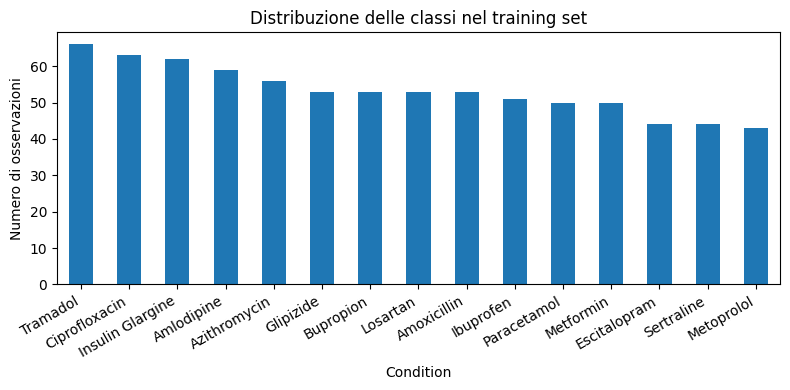

In [ ]:
# Distribuzione del target
class_counts = y_train.value_counts().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
class_counts.plot(kind="bar")
plt.title("Distribuzione delle classi nel training set")
plt.xlabel("Condition")
plt.ylabel("Numero di osservazioni")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

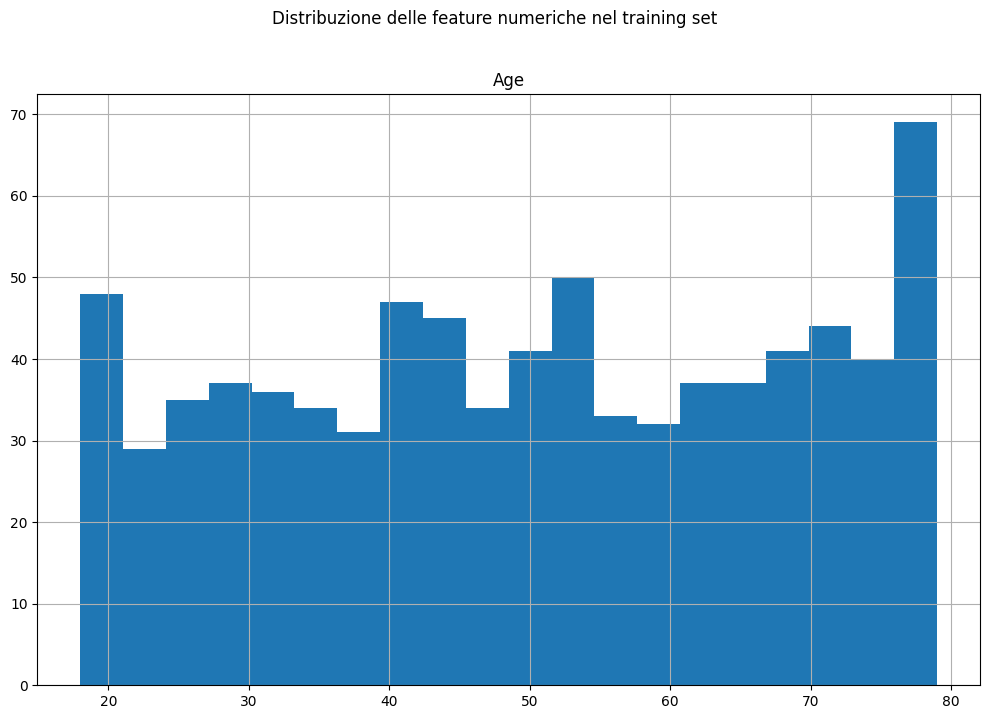

In [ ]:
# Distribuzioni delle feature numeriche
X_train[feature_numeriche].hist(figsize=(10, 7), bins=20)
plt.suptitle("Distribuzione delle feature numeriche nel training set", y=1.02)
plt.tight_layout()
plt.show()

Drug_Name,Amlodipine,Amoxicillin,Azithromycin,Bupropion,Ciprofloxacin,Escitalopram,Glipizide,Ibuprofen,Insulin Glargine,Losartan,Metformin,Metoprolol,Paracetamol,Sertraline,Tramadol
Condition,,,,,,,,,,,,,,,
Depression,0,0,0,53,0,44,0,0,0,0,0,0,0,44,0
Diabetes,0,0,0,0,0,0,53,0,62,0,50,0,0,0,0
Hypertension,59,0,0,0,0,0,0,0,0,53,0,43,0,0,0
Infection,0,53,56,0,63,0,0,0,0,0,0,0,0,0,0
Pain Relief,0,0,0,0,0,0,0,51,0,0,0,0,50,0,66


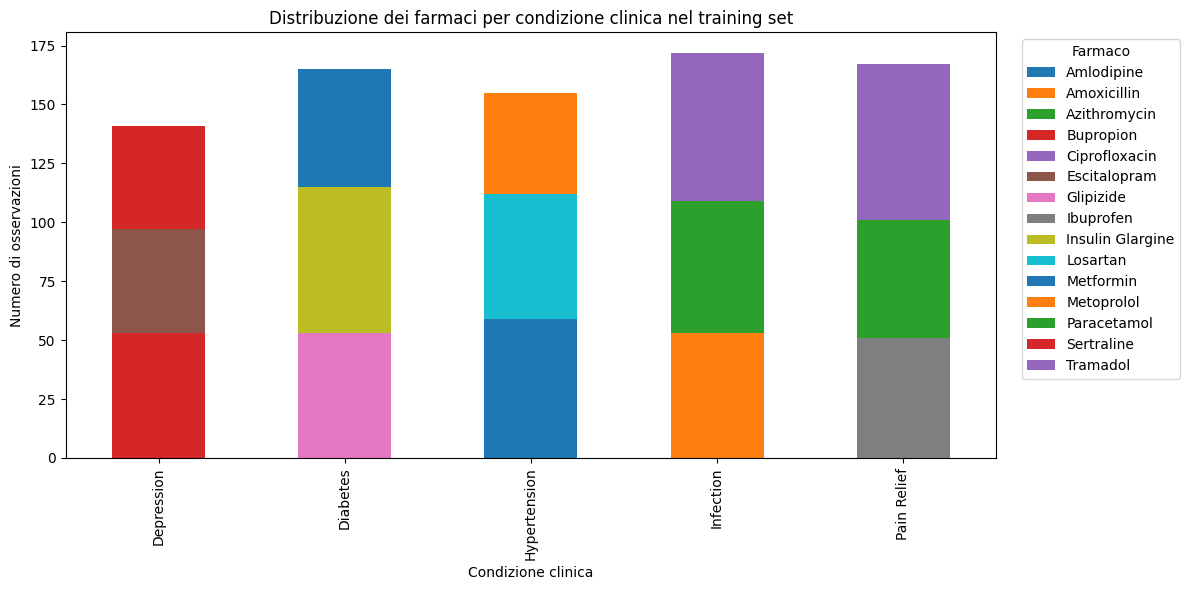

In [ ]:
# Relazione tra condizione clinica e farmaco nel training set
tabella_condition_drug = pd.crosstab(
    train_df["Condition"],
    train_df[TARGET]
)

display(tabella_condition_drug)

tabella_condition_drug.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)
plt.title("Distribuzione dei farmaci per condizione clinica nel training set")
plt.xlabel("Condizione clinica")
plt.ylabel("Numero di osservazioni")
plt.legend(title="Farmaco", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Prima osservazione importante

La variabile `Condition` restringe fortemente l'insieme dei farmaci possibili, ma non determina da sola un unico farmaco: nel dataset il primo insight che si trae è che ogni condizione è associata ad una combinazione di trattamento di tre farmaci sui 15 disponibili.

Il modello deve quindi distinguere tra farmaci appartenenti alla stessa area clinica usando anche `Age` e `Gender`.



## 5. Preprocessing con `ColumnTransformer` e `Pipeline`

Il dataset contiene feature numeriche e categoriche.

Per le feature numeriche:
- sostituiamo eventuali valori mancanti con la mediana;
- applichiamo la standardizzazione.

Per le feature categoriche:
- sostituiamo eventuali valori mancanti con la categoria più frequente;
- applichiamo il one-hot encoding.

La `Pipeline` garantisce che il preprocessing venga appreso soltanto sui dati di training, anche durante la cross-validation.

In [ ]:
preprocessore_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessore_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessore = ColumnTransformer(transformers=[
    ("num", preprocessore_numerico, feature_numeriche),
    ("cat", preprocessore_categorico, feature_categoriche)
])

print("Preprocessing e preparazione delle variabili fatta")

Preprocessing e preparazione delle variabili fatta


## 6. Baseline

Prima di valutare modelli più complessi, costruiamo una baseline con `DummyClassifier`.

La baseline non cerca pattern nelle feature. Prevede sempre e solo il farmaco più comune nel training set, per ogni paziente del test set. Serve come base di riferimento: se un modello come Logistic Regression, Decision Tree o Random Forest non fa meglio di così, vuol dire che non sta imparando nulla dai dati ma sta solo indovinando la classe maggioritaria.

In [ ]:
baseline = Pipeline(steps=[
    ("preprocessing", preprocessore),
    ("modello", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)

print("Accuracy baseline:", round(accuracy_score(y_test, pred_baseline), 3))
print("F1 macro baseline:", round(f1_score(y_test, pred_baseline, average="macro"), 3))

Accuracy baseline: 0.08
F1 macro baseline: 0.01


## 7. Confronto iniziale tra modelli con cross-validation

Confrontiamo tre modelli trattati o richiamati nel corso:

- Logistic Regression, come modello lineare di riferimento;
- Decision Tree, interpretabile ma sensibile all'overfitting;
- Random Forest, ensemble di molti alberi.

Non tocchiamo ancora il test set. Usiamo una cross-validation stratificata a 5 fold sul training set.

Per ciascuno dei 3 modelli si costruisce una `Pipeline` (preprocessing + modello), poi `cross_validate` allena e valuta il modello 5 volte (una per fold), calcolando sia `accuracy` che `f1_macro` ad ogni fold. Alla fine si calcola media e deviazione standard di queste metriche sui 5 fold.

In [ ]:
modelli = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

risultati_cv = []

for nome, modello in modelli.items():
    pipeline = Pipeline(steps=[
        ("preprocessing", preprocessore),
        ("modello", modello)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"},
        n_jobs=-1
    )

    risultati_cv.append({
        "Modello": nome,
        "Accuracy media": scores["test_accuracy"].mean(),
        "Dev. std. accuracy": scores["test_accuracy"].std(),
        "F1 macro medio": scores["test_f1_macro"].mean()
    })

confronto_cv = pd.DataFrame(risultati_cv).sort_values(
    "F1 macro medio", ascending=False
).reset_index(drop=True)

confronto_cv.round(3)

,Modello,Accuracy media,Dev. std. accuracy,F1 macro medio
0,Decision Tree,0.314,0.037,0.299
1,Random Forest,0.308,0.027,0.295
2,Logistic Regression,0.332,0.038,0.246


### Come leggere la tabella

- L'**accuracy** misura la quota totale di predizioni corrette.
- L'**F1 macro** calcola l'F1 separatamente per ogni classe e poi fa la media, dando lo stesso peso a tutte le classi.
- La **deviazione standard** mostra quanto il risultato cambia tra i fold: valori elevati indicano una stima meno stabile.

Il dato più interessante è che il ranking si inverte a seconda della metrica: **Logistic Regression** vince sull'accuracy ma è ultima sull'F1 macro; **Decision Tree** è prima sull'F1 macro; **Random Forest** è il modello con accuracy più bassa. Questo è coerente con quanto avevamo trovato prima: un modello lineare come Logistic Regression tende a "appiattirsi" di più sulla classe più frequente all'interno di ogni condizione (comportamento simile alla baseline che avevamo calcolato, che otteneva accuracy alta ma F1 macro bassissimo), mentre gli alberi riescono a catturare meglio i confini più irregolari tra i 3 farmaci di ogni condizione usando soglie su Age, migliorando il recall sulle classi minoritarie a scapito di qualche punto di accuracy.

Si è deciso di escludere il modello di **Logistic Regression** dal tuning perchè nelle prime valutazioni e dagli score test (tabella di Cross Validation) i valori ottenuti non sembravano giustificare ulteriori approfondimenti (F1 macro = 0.246). Si è dunque deciso di concentrarsi sul tuning del Decision Tree e della Random Forest.

## 8. Tuning del Decision Tree

Un albero senza limiti può imparare quasi a memoria il training set. Si regolano quindi alcuni iperparametri:

- `max_depth`: profondità massima;
- `min_samples_leaf`: numero minimo di osservazioni in una foglia;
- `criterion`: misura usata per valutare la qualità degli split.

`GridSearchCV` risulta utile per trovare automaticamente la combinazione ideale di iperparametri del modello e testa usando soltanto il training set.

In [ ]:
pipeline_tree = Pipeline(steps=[
    ("preprocessing", preprocessore),
    ("modello", DecisionTreeClassifier(random_state=SEED))
])

param_grid_tree = {
    "modello__max_depth": [3, 5, 8, None],
    "modello__min_samples_leaf": [1, 5, 10, 20],
    "modello__criterion": ["gini", "entropy"]
}

grid_tree = GridSearchCV(
    estimator=pipeline_tree,
    param_grid=param_grid_tree,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_tree.fit(X_train, y_train)

print("Migliori parametri:", grid_tree.best_params_)
print("Miglior F1 macro medio in CV:", round(grid_tree.best_score_, 3))

Migliori parametri: {'modello__criterion': 'entropy', 'modello__max_depth': None, 'modello__min_samples_leaf': 5}
Miglior F1 macro medio in CV: 0.304


## 9. Tuning della Random Forest

La Random Forest riduce la varianza del singolo albero aggregando molti alberi diversi. Manteniamo una griglia piccola per non rendere l'esecuzione troppo lenta.

In [ ]:
pipeline_rf = Pipeline(steps=[
    ("preprocessing", preprocessore),
    ("modello", RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

param_grid_rf = {
    "modello__n_estimators": [100, 250],
    "modello__max_depth": [None, 6, 10],
    "modello__min_samples_leaf": [1, 5, 10],
    "modello__max_features": ["sqrt", None]
}

grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Migliori parametri:", grid_rf.best_params_)
print("Miglior F1 macro medio in CV:", round(grid_rf.best_score_, 3))

Migliori parametri: {'modello__max_depth': None, 'modello__max_features': 'sqrt', 'modello__min_samples_leaf': 5, 'modello__n_estimators': 100}
Miglior F1 macro medio in CV: 0.306


## 10. Scelta del modello e test finale

Scegliamo automaticamente il modello con il miglior F1 macro medio ottenuto durante il tuning. Soltanto ora lo valutiamo sul test set, che non è stato usato per prendere decisioni.

In [ ]:
if grid_rf.best_score_ >= grid_tree.best_score_:
    modello_finale = grid_rf.best_estimator_
    nome_modello_finale = "Random Forest"
else:
    modello_finale = grid_tree.best_estimator_
    nome_modello_finale = "Decision Tree"

pred_finali = modello_finale.predict(X_test)

accuracy_finale = accuracy_score(y_test, pred_finali)
f1_finale = f1_score(y_test, pred_finali, average="macro")

print("Modello selezionato:", nome_modello_finale)
print("Accuracy sul test set:", round(accuracy_finale, 3))
print("F1 macro sul test set:", round(f1_finale, 3))

Modello selezionato: Random Forest
Accuracy sul test set: 0.37
F1 macro sul test set: 0.345


In [ ]:
print(classification_report(y_test, pred_finali, digits=3))

                  precision    recall  f1-score   support

      Amlodipine      0.450     0.600     0.514        15
     Amoxicillin      0.308     0.308     0.308        13
    Azithromycin      0.222     0.143     0.174        14
       Bupropion      0.500     0.692     0.581        13
   Ciprofloxacin      0.381     0.500     0.432        16
    Escitalopram      0.286     0.182     0.222        11
       Glipizide      0.308     0.286     0.296        14
       Ibuprofen      0.353     0.462     0.400        13
Insulin Glargine      0.312     0.312     0.312        16
        Losartan      0.250     0.231     0.240        13
       Metformin      0.308     0.333     0.320        12
      Metoprolol      0.000     0.000     0.000        11
     Paracetamol      0.400     0.167     0.235        12
      Sertraline      0.600     0.545     0.571        11
        Tramadol      0.526     0.625     0.571        16

        accuracy                          0.370       200
       macro

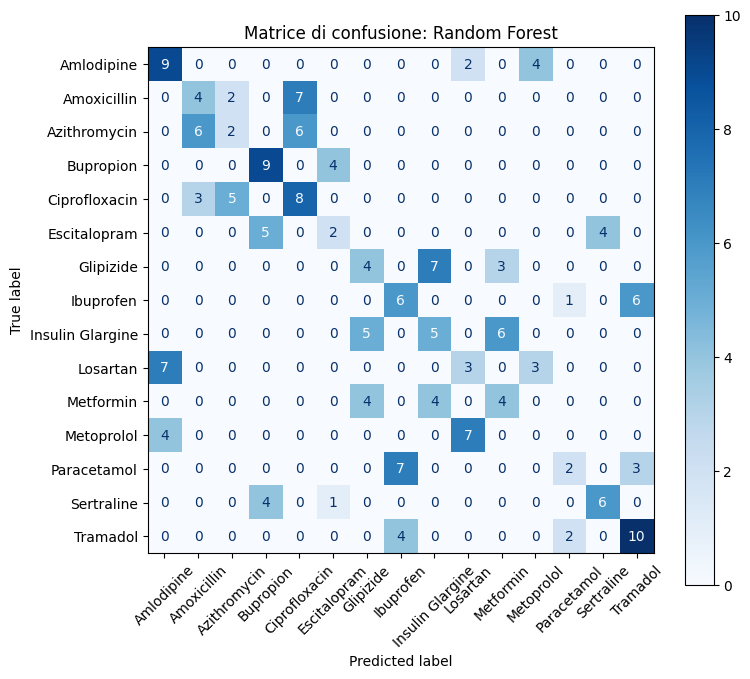

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_finali,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax
)
plt.title(f"Matrice di confusione: {nome_modello_finale}")
plt.tight_layout()
plt.show()

### Interpretazione della matrice di confusione

- La diagonale contiene i farmaci classificati correttamente.
- Le celle fuori diagonale mostrano quali farmaci vengono confusi tra loro.
- È particolarmente utile verificare se le confusioni avvengono tra farmaci associati alla stessa condizione clinica.
- Non basta osservare l'accuracy complessiva: alcune classi potrebbero essere riconosciute meglio di altre.

Guardando dove cade la massa fuori diagonale, si conferma che il modello confonde quasi solo farmaci della stessa condizione clinica. Per esempio:

- Amoxicillin/Azithromycin/Ciprofloxacin (**Infection**) si scambiano tra loro (7, 6, 6, 5, 3, 2...) ma quasi mai finiscono fuori dal gruppo Infection.
- Glipizide/Insulin Glargine/Metformin (**Diabetes**): Metformin vero è previsto in modo perfettamente equidistribuito tra i 3 farmaci Diabetes (4/4/4). Avviene come un'estrazione a sorte tra 3 opzioni.
- Bupropion/Escitalopram/Sertraline (**Depression**) si scambiano quasi solo tra loro.

Questo conferma che il modello ha imparato bene qual è la condizione, molto meno "quale farmaco specifico dentro la condizione".

`Ibuprofen` rappresenta una delle classi più difficili da riconoscere. Il modello identifica correttamente solo 6 osservazioni su 13, mentre altre 6 vengono classificate come Tramadol. Questo suggerisce che, sulla base delle feature disponibili (Age, Gender e Condition), il modello non dispone di informazioni sufficienti per distinguere in modo affidabile tra questi due analgesici.


## 11. Interpretabilità del Decision Tree

Anche quando la Random Forest risulta migliore, un singolo albero può essere utile per capire la logica delle decisioni. Visualizziamo il miglior Decision Tree limitando il grafico ai primi tre livelli.

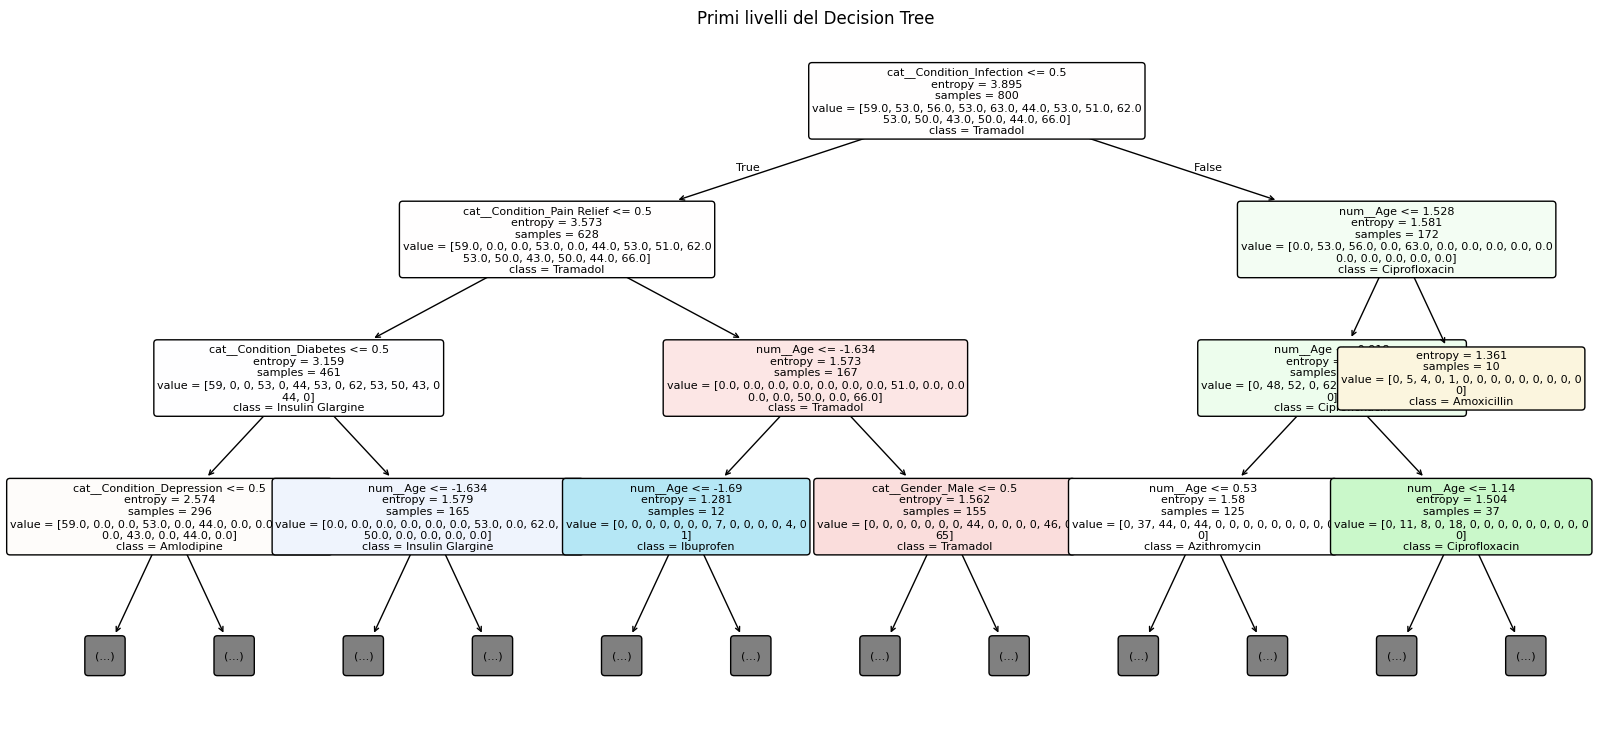

In [ ]:
# Recuperiamo i nomi delle feature dopo il one-hot encoding
best_tree_pipeline = grid_tree.best_estimator_
best_tree_model = best_tree_pipeline.named_steps["modello"]
feature_names = best_tree_pipeline.named_steps["preprocessing"].get_feature_names_out()

plt.figure(figsize=(20, 9))
plot_tree(
    best_tree_model,
    feature_names=feature_names,
    class_names=best_tree_model.classes_.astype(str),
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Primi livelli del Decision Tree")
plt.show()

## 12. Importanza delle feature nella Random Forest

L'importanza indica quanto le feature hanno contribuito agli split degli alberi. Non dimostra un rapporto causale e può favorire feature con molte modalità, quindi va letta come strumento esplorativo.

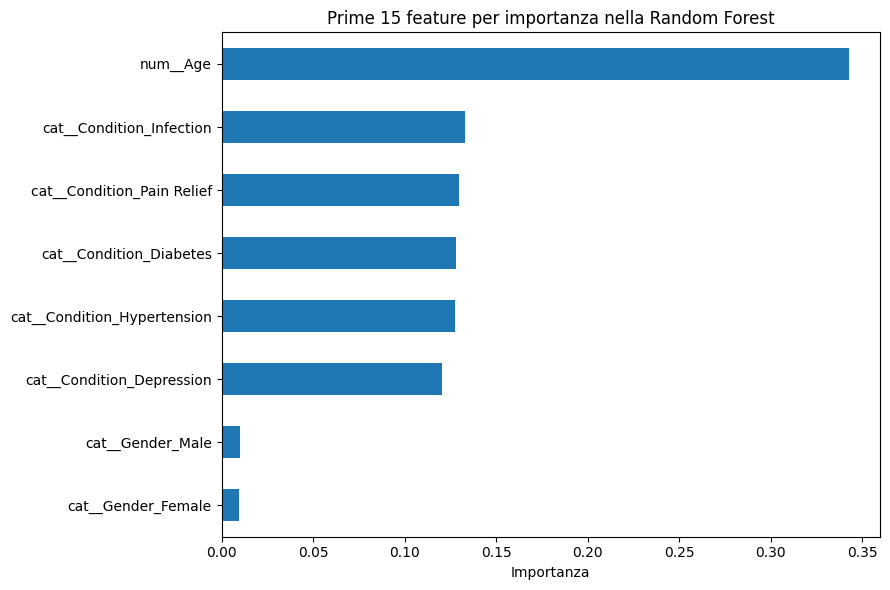

In [ ]:
best_rf_pipeline = grid_rf.best_estimator_
best_rf_model = best_rf_pipeline.named_steps["modello"]
rf_feature_names = best_rf_pipeline.named_steps["preprocessing"].get_feature_names_out()

importanze = pd.Series(
    best_rf_model.feature_importances_,
    index=rf_feature_names
).sort_values(ascending=False).head(15)

importanze.sort_values().plot(kind="barh", figsize=(9, 6))
plt.title("Prime 15 feature per importanza nella Random Forest")
plt.xlabel("Importanza")
plt.tight_layout()
plt.show()

# Parte II: perché il modello non riconosce mai Ibuprofen?

## 13. Motivazione e scelta del nuovo task

Nella Parte I abbiamo osservato, dalla matrice di confusione, un risultato specifico: il modello multiclasse **non prevede correttamente `Ibuprofen`** (6 su 13 previsioni corrette su tutti i casi veri nel test set), nonostante riconosca abbastanza bene altri farmaci dello stesso gruppo clinico (`Pain Relief`).

Invece di introdurre un nuovo target scollegato dal resto del progetto, la Parte II **resta sul target originale `Drug_Name`** e approfondisce proprio questo risultato, trasformandolo in un problema più semplice e mirato:

> Tra i pazienti con `Condition == "Pain Relief"`, possiamo prevedere se un paziente riceve **Ibuprofen** (1) oppure uno degli altri due farmaci dello stesso gruppo (0), usando solo `Age` e `Gender`?

`Condition` non viene più usata come feature in questa sezione: è costante all'interno del sottoinsieme (`Pain Relief`), quindi non porterebbe alcuna informazione utile a distinguere i pazienti.

Il resto del workflow segue **esattamente la stessa struttura metodologica della Parte I**: split stratificato, baseline, confronto tra modelli in cross-validation, tuning con `GridSearchCV`, valutazione finale sul test set, interpretazione tramite matrice di confusione, curva Precision-Recall e curva ROC.

In [ ]:
df_pain = df[df["Condition"] == "Pain Relief"].copy()

TARGET_BIN = "is_ibuprofen"
df_pain[TARGET_BIN] = (df_pain["Drug_Name"] == "Ibuprofen").astype(int)

feature_numeriche_ib = ["Age"]
feature_categoriche_ib = ["Gender"]
feature_usate_ib = feature_numeriche_ib + feature_categoriche_ib

X_ib = df_pain[feature_usate_ib].copy()
y_ib = df_pain[TARGET_BIN].copy()

print("Pazienti con Condition == 'Pain Relief':", df_pain.shape[0])
print("Feature utilizzate:", feature_usate_ib)
print("Target: is_ibuprofen (1 = Ibuprofen, 0 = altro farmaco del gruppo Pain Relief)")
print("\nDistribuzione del target:")
display(y_ib.value_counts(normalize=True).round(3).to_frame("proporzione"))

Pazienti con Condition == 'Pain Relief': 208
Feature utilizzate: ['Age', 'Gender']
Target: is_ibuprofen (1 = Ibuprofen, 0 = altro farmaco del gruppo Pain Relief)

Distribuzione del target:


,proporzione
is_ibuprofen,
0,0.692
1,0.308


## 14. Train/test split (stesso criterio della Parte I)

Come nella Parte I, separiamo il test set **prima** di ogni preprocessing, con split stratificato sul target per mantenere le stesse proporzioni di classe in training e test.

In [ ]:
X_train_ib, X_test_ib, y_train_ib, y_test_ib = train_test_split(
    X_ib,
    y_ib,
    test_size=0.20,
    random_state=SEED,
    stratify=y_ib
)

print("Training set:", X_train_ib.shape)
print("Test set:", X_test_ib.shape)

print("\nDistribuzione percentuale nel training set:")
print(y_train_ib.value_counts(normalize=True).round(3))

Training set: (166, 2)
Test set: (42, 2)

Distribuzione percentuale nel training set:
is_ibuprofen
0    0.693
1    0.307
Name: proportion, dtype: float64


## 15. Preprocessing e baseline

Riutilizziamo la stessa logica di preprocessing della Parte I (`ColumnTransformer` con imputazione e standardizzazione per `Age`, imputazione e one-hot encoding per `Gender`), incapsulata in una `Pipeline` per evitare data leakage tra i fold.

La baseline resta un `DummyClassifier` che predice sempre la classe più frequente (0 = "non Ibuprofen"). Qui il target è binario e non fortemente sbilanciato (~31% Ibuprofen), ma restiamo comunque su F1 (non macro, essendoci solo 2 classi) per valutare in particolare quanto bene il modello riconosce la classe positiva.

In [ ]:
preprocessore_ib = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), feature_numeriche_ib),
    ("cat", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), feature_categoriche_ib)
])

baseline_ib = Pipeline(steps=[
    ("preprocessing", preprocessore_ib),
    ("modello", DummyClassifier(strategy="most_frequent"))
])

baseline_ib.fit(X_train_ib, y_train_ib)
pred_baseline_ib = baseline_ib.predict(X_test_ib)

print("Accuracy baseline:", round(accuracy_score(y_test_ib, pred_baseline_ib), 3))
print("F1 baseline (classe Ibuprofen):", round(f1_score(y_test_ib, pred_baseline_ib), 3))

Accuracy baseline: 0.69
F1 baseline (classe Ibuprofen): 0.0


## 16. Confronto tra modelli con cross-validation

Confrontiamo gli stessi tre modelli della Parte I, con la stessa `StratifiedKFold` a 5 fold, sul training set.

In [ ]:
modelli_ib = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
}

risultati_cv_ib = []

for nome, modello in modelli_ib.items():
    pipeline = Pipeline(steps=[
        ("preprocessing", preprocessore_ib),
        ("modello", modello)
    ])

    scores = cross_validate(
        pipeline,
        X_train_ib,
        y_train_ib,
        cv=cv,
        scoring={"accuracy": "accuracy", "f1": "f1"},
        n_jobs=-1
    )

    risultati_cv_ib.append({
        "Modello": nome,
        "Accuracy media": scores["test_accuracy"].mean(),
        "Dev. std. accuracy": scores["test_accuracy"].std(),
        "F1 medio (classe Ibuprofen)": scores["test_f1"].mean()
    })

confronto_cv_ib = pd.DataFrame(risultati_cv_ib).sort_values(
    "F1 medio (classe Ibuprofen)", ascending=False
).reset_index(drop=True)

confronto_cv_ib.round(3)

,Modello,Accuracy media,Dev. std. accuracy,F1 medio (classe Ibuprofen)
0,Decision Tree,0.639,0.091,0.272
1,Random Forest,0.609,0.094,0.255
2,Logistic Regression,0.669,0.047,0.000


### Nota: perché qui includiamo anche `class_weight` nel tuning

A differenza della Parte I, qui il target è moderatamente sbilanciato (~31% / ~69%). Un modello di default tende a "convenirgli" prevedere quasi sempre la classe maggioritaria, ottenendo F1 vicino a zero sulla classe minoritaria pur avendo un'accuracy apparentemente accettabile — lo stesso comportamento già incontrato con la baseline nella Parte I.

Per questo motivo, nella fase di tuning includiamo anche l'iperparametro `class_weight="balanced"`, che penalizza maggiormente gli errori sulla classe minoritaria durante l'addestramento.

## 17. Tuning di Decision Tree e Random Forest

In [ ]:
pipeline_tree_ib = Pipeline(steps=[
    ("preprocessing", preprocessore_ib),
    ("modello", DecisionTreeClassifier(random_state=SEED))
])

param_grid_tree_ib = {
    "modello__max_depth": [2, 3, 4, 5, None],
    "modello__min_samples_leaf": [1, 5, 10, 20],
    "modello__class_weight": [None, "balanced"]
}

grid_tree_ib = GridSearchCV(
    estimator=pipeline_tree_ib,
    param_grid=param_grid_tree_ib,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_tree_ib.fit(X_train_ib, y_train_ib)

print("Migliori parametri (Decision Tree):", grid_tree_ib.best_params_)
print("Miglior F1 medio in CV:", round(grid_tree_ib.best_score_, 3))

pipeline_rf_ib = Pipeline(steps=[
    ("preprocessing", preprocessore_ib),
    ("modello", RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

param_grid_rf_ib = {
    "modello__n_estimators": [100, 250],
    "modello__max_depth": [None, 4, 8],
    "modello__min_samples_leaf": [1, 5, 10],
    "modello__class_weight": [None, "balanced"]
}

grid_rf_ib = GridSearchCV(
    estimator=pipeline_rf_ib,
    param_grid=param_grid_rf_ib,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_rf_ib.fit(X_train_ib, y_train_ib)

print("Migliori parametri (Random Forest):", grid_rf_ib.best_params_)
print("Miglior F1 medio in CV:", round(grid_rf_ib.best_score_, 3))

Migliori parametri (Decision Tree): {'modello__class_weight': 'balanced', 'modello__max_depth': None, 'modello__min_samples_leaf': 5}
Miglior F1 medio in CV: 0.489
Migliori parametri (Random Forest): {'modello__class_weight': 'balanced', 'modello__max_depth': None, 'modello__min_samples_leaf': 5, 'modello__n_estimators': 100}
Miglior F1 medio in CV: 0.453


## 18. Scelta del modello e valutazione finale sul test set

Come nella Parte I, scegliamo automaticamente il modello con il miglior F1 medio ottenuto in cross-validation, e lo valutiamo **una sola volta** sul test set.

Modello selezionato: Decision Tree
Accuracy sul test set: 0.548
F1 sul test set (classe Ibuprofen): 0.513
ROC AUC sul test set: 0.58
              precision    recall  f1-score   support

           0      0.812     0.448     0.578        29
           1      0.385     0.769     0.513        13

    accuracy                          0.548        42
   macro avg      0.599     0.609     0.545        42
weighted avg      0.680     0.548     0.558        42



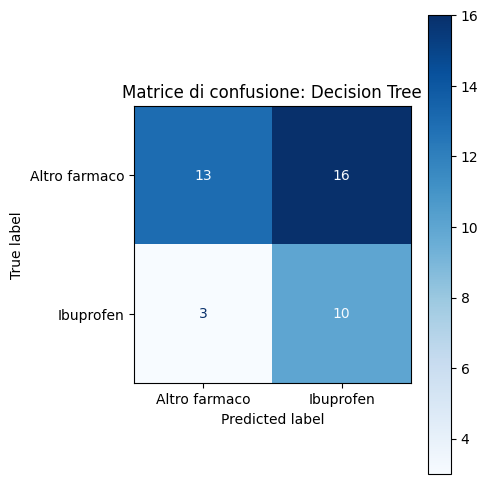

In [ ]:
if grid_rf_ib.best_score_ >= grid_tree_ib.best_score_:
    modello_finale_ib = grid_rf_ib.best_estimator_
    nome_modello_finale_ib = "Random Forest"
else:
    modello_finale_ib = grid_tree_ib.best_estimator_
    nome_modello_finale_ib = "Decision Tree"

pred_finali_ib = modello_finale_ib.predict(X_test_ib)
prob_finali_ib = modello_finale_ib.predict_proba(X_test_ib)[:, 1]

accuracy_finale_ib = accuracy_score(y_test_ib, pred_finali_ib)
f1_finale_ib = f1_score(y_test_ib, pred_finali_ib)
auc_finale_ib = roc_auc_score(y_test_ib, prob_finali_ib)

print("Modello selezionato:", nome_modello_finale_ib)
print("Accuracy sul test set:", round(accuracy_finale_ib, 3))
print("F1 sul test set (classe Ibuprofen):", round(f1_finale_ib, 3))
print("ROC AUC sul test set:", round(auc_finale_ib, 3))

print(classification_report(y_test_ib, pred_finali_ib, digits=3))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_ib,
    pred_finali_ib,
    display_labels=["Altro farmaco", "Ibuprofen"],
    cmap="Blues",
    ax=ax
)
plt.title(f"Matrice di confusione: {nome_modello_finale_ib}")
plt.tight_layout()
plt.show()

## 19. Curva Precision-Recall e scelta della soglia

Come nella Parte I originale, esploriamo il compromesso precision/recall al variare della soglia di decisione. Qui ha senso privilegiare il **recall**: l'obiettivo diagnostico è individuare quanti più pazienti Ibuprofen possibile, anche a costo di qualche falso positivo.


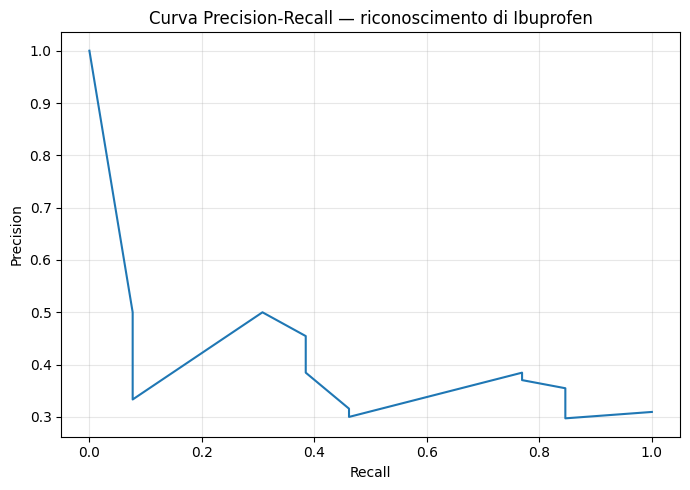

Soglia scelta: 0.429
Precision ottenuta: 0.355
Recall ottenuto: 0.846


In [ ]:
precision_ib, recall_ib, soglie_pr_ib = precision_recall_curve(y_test_ib, prob_finali_ib)

plt.figure(figsize=(7, 5))
plt.plot(recall_ib, precision_ib)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — riconoscimento di Ibuprofen")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Cerchiamo una soglia con recall almeno pari all'80%
recall_desiderato = 0.80
indici_validi_ib = np.where(recall_ib[:-1] >= recall_desiderato)[0]

if len(indici_validi_ib) > 0:
    indice_ib = indici_validi_ib[np.argmax(precision_ib[:-1][indici_validi_ib])]
    soglia_scelta_ib = soglie_pr_ib[indice_ib]

    pred_soglia_ib = (prob_finali_ib >= soglia_scelta_ib).astype(int)

    print("Soglia scelta:", round(float(soglia_scelta_ib), 3))
    print("Precision ottenuta:", round(precision_score(y_test_ib, pred_soglia_ib), 3))
    print("Recall ottenuto:", round(recall_score(y_test_ib, pred_soglia_ib), 3))
else:
    print("Non è stata trovata una soglia con il recall richiesto.")

## 20. Curva ROC

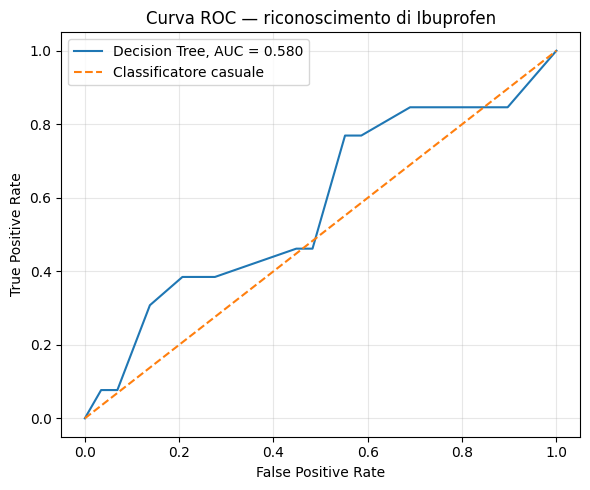

In [ ]:
fpr_ib, tpr_ib, soglie_roc_ib = roc_curve(y_test_ib, prob_finali_ib)

plt.figure(figsize=(6, 5))
plt.plot(fpr_ib, tpr_ib, label=f"{nome_modello_finale_ib}, AUC = {auc_finale_ib:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Classificatore casuale")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — riconoscimento di Ibuprofen")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 21. Conclusioni del progetto

### Task principale: previsione multiclasse di `Drug_Name`

- La Random Forest ottimizzata ha ottenuto il miglior risultato, con un F1 macro medio di circa 0,306.
- Rispetto alla baseline DummyClassifier (F1 macro ≈ 0,01), il miglior modello migliora di circa 0,30 punti. Rispetto alla baseline informata basata solo su `Condition`, il miglioramento è invece limitato, perché la condizione clinica è già molto informativa per prevedere il farmaco.
- La variabilità è contenuta: la deviazione standard dell'accuracy è compresa tra circa 0,03 e 0,04, quindi i risultati sono abbastanza stabili.
- Gli errori avvengono soprattutto tra farmaci usati per la stessa condizione clinica, perché hanno caratteristiche molto simili nelle feature disponibili.
- Ad esempio `Metoprolol` non viene mai riconosciuto correttamente nel test. Probabilmente perché le feature disponibili (età, genere e condizione) non sono sufficienti a distinguerlo da altri farmaci della stessa categoria.
- Il tuning migliora davvero il Decision Tree e la Random Forest ma il miglioramento è modesto. Il tuning aumenta leggermente il F1 macro e permette di ottenere modelli un po' più efficaci.
`Condition`, mentre `Age` e `Gender` hanno un impatto molto inferiore sulla previsione del farmaco.


### Insights dell' approfondimento: riconoscimento di Ibuprofen (Parte II)

- Il modello riconosce meglio Ibuprofen isolando il problema rispetto al task multiclasse completo. Nel task binario il modello riesce a identificare molti casi di Ibuprofen (recall ≈ 77%), mentre nel task multiclasse non lo prevedeva mai correttamente.
- La ROC AUC è 0,58. È solo leggermente migliore del caso casuale (0,50): il modello distingue Ibuprofen meglio del task principale, ma la capacità discriminante resta limitata.
- class_weight="balanced" ha fatto la differenza nel tuning. È stato scelto come miglior parametro sia per il Decision Tree sia per la Random Forest, perché ha migliorato il riconoscimento della classe minoritaria (Ibuprofen), aumentando il recall e l'F1.
- è stato trovato un compromesso che emerge tra precision e recall imponendo un recall almeno pari all'80%. Per ottenere un recall dell'84,6%, la precision scende al 35,5%. Quindi il modello trova quasi tutti i casi di Ibuprofen, ma produce anche molti falsi positivi.
- Questo approfondimento aiuta a spiegare perché, nel task principale, Ibuprofen non veniva mai previsto correttamente. Anche isolando il problema, il modello fatica a distinguere Ibuprofen dagli altri farmaci. Nel task multiclasse questa difficoltà aumenta ulteriormente, portando il modello a non prevedere mai correttamente la classe Ibuprofen.


### Limiti del progetto

- Il dataset non può rappresentare l'intera complessità delle decisioni cliniche.
- Le feature disponibili sono poche (solo `Age` e `Gender` oltre a `Condition`).
- Una buona prestazione predittiva non implica una relazione causale.
- Il sottoinsieme usato nella Parte II (`Pain Relief`) è più piccolo del dataset completo: le stime sono meno stabili.


# 22. Uso dell'Intelligenza Artificiale generativa

Per la preparazione del progetto sono stati utilizzati strumenti di Intelligenza Artificiale generativa quali ChatGPT e Claude. Sono serviti come supporto alla riorganizzazione del notebook e alla revisione del codice, inclusa la riprogettazione della Parte II (a seguito di un collegamento logico mancante riscontrato) per renderla coerente con il target scelto fin dall'inizio (`Drug_Name`), a partire da un'osservazione emersa dalla matrice di confusione della Parte I. Infine Replit è stato utilizzato attraverso diversi prompt per fornire lo schema di presentazione.

